# 1. Wstęp Teoretyczny i Architektura Algorytmu

## 1.1. Podstawy Algorytmu Genetycznego (SGA)
Klasyczny Algorytm Genetyczny (*Simple Genetic Algorithm* - SGA) to metaheurystyczna technika optymalizacyjna inspirowana mechanizmami naturalnej ewolucji i genetyki. Przeszukuje ona przestrzeń rozwiązań, modelując zjawiska takie jak dziedziczenie, zmienność (mutacje) oraz dobór naturalny (przeżywalność najlepiej przystosowanych jednostek). W przeciwieństwie do analitycznych metod gradientowych, SGA pracuje na całej populacji potencjalnych rozwiązań, co znacząco zmniejsza ryzyko utknięcia algorytmu w minimach lokalnych.

## 1.2. Przebieg Pojedynczej Epoki (Cykl Ewolucyjny)
Proces optymalizacji w zaimplementowanym systemie realizowany jest poprzez cykliczne powtarzanie epok (pokoleń), z których każda składa się z następujących etapów:

1. **Ocena Przystosowania (Evaluation):** Każdy osobnik w populacji jest oceniany za pomocą funkcji celu (w badaniu: *Hypersphere*). Ponieważ problemem bazowym jest **minimalizacja**, surowa wartość funkcji sferycznej przekształcana jest na tzw. funkcję przystosowania (*Fitness*) za pomocą wzoru odwracającego:
   $$Fitness = \frac{1}{1 + f(\mathbf{x})}$$
   Dzięki temu rozwiązanie o wartości $f(\mathbf{x}) \approx 0$ otrzymuje maksymalną ocenę przystosowania dążącą do $1.0$, co pozwala mechanizmom selekcji na poprawne działanie.
   
2. **Elitaryzm (Elitism):** Zanim rozpocznie się proces reprodukcji, ustaloną liczbę najlepszych osobników (tzw. elitę) kopiuje się bezpośrednio do nowej populacji bez żadnych modyfikacji. Chroni to najlepszy dotychczasowy materiał genetyczny przed zniszczeniem przez operatory mutacji i krzyżowania.

3. **Selekcja (Selection):** Wybór par rodzicielskich do rozrodu. W ramach projektu zaimplementowałam trzy metody:
   * *Turniejowa* – losowanie $N$ osobników i wybór najlepszego z nich (zapewnia doskonałą presję ewolucyjną).
   * *Ruletkowa* – szansa na wybór jest proporcjonalna do wartości *Fitness* osobnika.
   * *Wybór Najlepszych (Best)* – deterministyczne krzyżowanie tylko z czołówką populacji.

4. **Krzyżowanie (Crossover):** Z określonym prawdopodobieństwem ($P_c$) para rodziców wymienia się materiałem genetycznym, tworząc dwoje potomków. System obsługuje krzyżowanie jedno-punktowe, dwu-punktowe, jednorodne (uniform) oraz ziarniste (grainy).

5. **Mutacja (Mutation) i Inwersja:** Każdy nowo powstały potomek poddawany jest potencjalnym błędom kopiowania genów. Z prawdopodobieństwem ($P_m$) poszczególne bity chromosomu mogą zostać zanegowane (*Bit Flip*). Dodatkowo zdefiniowano operator inwersji odwracający kolejność fragmentu chromosomu, co wprowadza dodatkową dywersyfikację w populacji.

<br>


## 2. Reprezentacja Danych (Opis Kodowania)

Algorytm wykorzystuje **kodowanie binarne**. Pojedynczy osobnik (rozwiązanie) reprezentowany jest jako długi łańcuch genów o wartościach `0` i `1` (chromosom). 

Dla problemu $N$-wymiarowego, chromosom dzielony jest na równe segmenty (tzw. podchromosomy), z których każdy reprezentuje jedną zmienną decyzyjną $x_i$. Długość pojedynczego segmentu ($L$) określa precyzję obliczeń.

### Proces Dekodowania (Fenotyp)
Aby obliczyć wartość funkcji sferycznej, binarny łańcuch znaków musi zostać rzutowany na wartość rzeczywistą w zadanej dziedzinie, u nas: $[-5, 5]$. Realizowane jest to poprzez standardowe dekodowanie afiniczne (liniowe), zdefiniowane poniższym wzorem matematycznym:

$$x_{real} = x_{min} + D \cdot \frac{x_{max} - x_{min}}{2^L - 1}$$

Gdzie:
* $x_{real}$ – szukana wartość rzeczywista zmiennej,
* $x_{min}, x_{max}$ – granice przedziału (dziedzina poszukiwań, odpowiednio $-5$ i $5$),
* $D$ – wartość dziesiętna rozkodowana z fragmentu binarnego,
* $L$ – liczba bitów przeznaczona na pojedynczą zmienną.

Takie podejście gwarantuje, że algorytm przeszukuje ciągłą przestrzeń rozwiązań z precyzją wynikającą bezpośrednio z długości przyjętego łańcucha binarnego.

<br>


## 3. Technologie użyte w projekcie

Projekt został zrealizowany w języku **Python**, z wykorzystaniem nowoczesnych bibliotek do obliczeń naukowych, wizualizacji oraz analizy danych. Wybór technologii podyktowany był koniecznością zapewnienia wysokiej wydajności obliczeniowej oraz przejrzystości prezentowanych wyników.

* **Język programowania:** Python 3.10+ (główna logika algorytmu genetycznego).
* **Interfejs graficzny (GUI):** `Tkinter` – wykorzystany do stworzenia interaktywnego panelu badawczego, pozwalającego na dynamiczną zmianę parametrów eksperymentu.
* **Wizualizacja:** `Matplotlib` – użyty do generowania wykresów zbieżności oraz dynamicznego renderowania wyników w oknie aplikacji i notatniku.
* **Analiza Danych:** `Pandas` – wykorzystany w procesie post-processingu danych zapisanych w formacie CSV, umożliwiający szybkie filtrowanie i porównywanie wyników.
* **Środowisko badawcze:** `Jupyter Notebook` – platforma wykorzystana do automatyzacji generowania sprawozdania i zbiorczej analizy wielu plików logów.
* **Zarządzanie logami:** Zapis parametrów (`.txt`) oraz historii ewolucji (`.csv`) do plików.

<br>


## 4. Wymagania środowiskowe

Do poprawnego uruchomienia aplikacji oraz skryptów analitycznych wymagane jest środowisko Python z zainstalowanymi zależnościami wymienionymi poniżej.

### Wymagania programowe:
* **Interpreter:** Python (wersja 3.8 lub nowsza).
* **Biblioteki zewnętrzne (instalacja za pomocą pip):**
    ```bash
    pip install matplotlib pandas notebook
    ```

<br>


## 5. Opis wybranych funkcji testowych i ich optima

W badaniach nad skutecznością zaimplementowanego Algorytmu Genetycznego wykorzystano funkcję **Hypersphere**. Jest to klasyczna funkcja testowa, charakteryzująca się unimodalnością, co pozwala na precyzyjną ocenę zdolności algorytmu do lokalizacji minimum globalnego bez ryzyka utknięcia w minimach lokalnych.

### Definicja matematyczna:
Funkcja ta jest zdefiniowana jako suma kwadratów zmiennych decyzyjnych $x_i$:

$$f(\mathbf{x}) = \sum_{i=1}^{n} x_i^2$$

### Parametry badania:
* **Wymiarowość (N):** Badania przeprowadzono dla $N \in \{2, 10, 27\}$.
* **Dziedzina poszukiwań:** Każda zmienna $x_i$ ograniczona jest przedziałem $[-5, 5]$.
* **Charakterystyka:** Funkcja jest ciągła, wypukła i różniczkowalna.

### Optimum globalne:
Algorytm dąży do znalezienia wektora wartości, dla którego funkcja przyjmuje wartość minimalną:
* **Punkt optimum:** $\mathbf{x}^* = (0, 0, \dots, 0)$
* **Wartość optimum:** $f(\mathbf{x}^*) = 0$

W przypadku testów maksymalizacji, ze względu na symetrię dziedziny $[-5, 5]$, punkty optymalne znajdują się na krawędziach przestrzeni poszukiwań (np. wektory składające się z samych piątek), gdzie wartość funkcji wynosi:
$$f(\mathbf{x}_{max}) = n \cdot 5^2$$
Dla $N=5$, maksimum wynosi dokładnie **125.0**, co zostało potwierdzone podczas testów metod krzyżowania.

<br>


## Środowisko i narzędzia analityczne

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob

# wykresy - ustawienia
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# dane
LOGS_DIR = 'results/logs'
SUMMARY_FILE = 'results/summary/global_summary.csv'

print("✅ Środowisko gotowe. Biblioteki załadowane.")

✅ Środowisko gotowe. Biblioteki załadowane.


## Ranking najlepszych

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

df_summary = pd.read_csv('results/summary/global_summary.csv')

df_p1 = df_summary[df_summary['ga_type'] == 'Binary'].copy()

df_p1 = df_p1.sort_values(by='best_value', ascending=True)

print("Ranking eksperymentów :")
display(df_p1[['experiment_name', 'crossover_method', 'mutation_method', 'pop_size', 'best_value', 'execution_time']])

Ranking eksperymentów :


,experiment_name,crossover_method,mutation_method,pop_size,best_value,execution_time
15,Dimensions_2_Test,uniform,bit_flip,50,0.000000,0.3495
23,Single-Point_Mutation_Test,uniform,single_point,50,0.000000,0.1745
24,Two_Point_Mutation_Test,uniform,two_point,50,0.000000,0.1806
14,Roulette-Selection_Test,uniform,bit_flip,50,0.001474,0.5285
18,One-Point_Crossover_Test,one_point,bit_flip,50,0.006706,0.4117
3,Elite_5_Test,uniform,bit_flip,50,0.008198,0.4299
22,Boundary_Mutation_Test,uniform,boundary,50,0.012120,0.1956
9,Population_50_Test,uniform,bit_flip,50,0.012677,0.4209
19,Two-Point_Crossover_Test,two_point,bit_flip,50,0.016634,0.4047
13,Best-Selection_Test,uniform,bit_flip,50,0.018030,0.4156


## Wpływ rodzaju krzyżowania na stabilność algorytmu

ℹ️ Do analizy krzyżowania użyto 19 eksperymentów.
ℹ️ Odrzucono 5 eksperyment/ów (optymalizacja MAX).


C:\Users\wikto\AppData\Local\Temp\ipykernel_7360\1606652107.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_p1_filtered, x='crossover_method', y='best_value', palette='Set2', width=0.5)


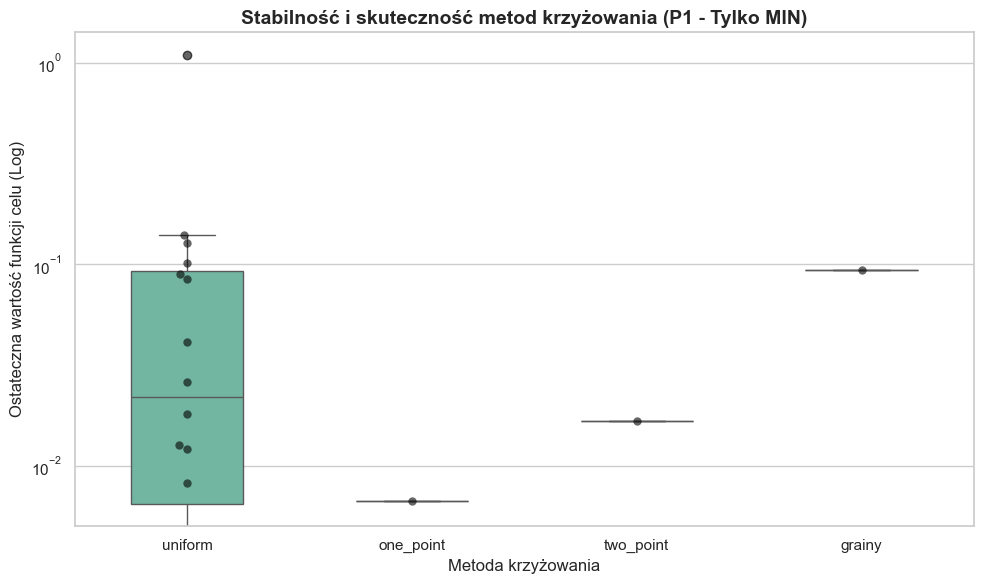

In [34]:
plt.figure(figsize=(10, 6))

# --- FILTROWANIE DANYCH ---
# Poprawne wyniki MIN są mniejsze niż 5.0. 
# Wszystko, co ma ogromną wartość (bo było optymalizowane pod MAX), zostanie odrzucone.
df_p1_filtered = df_p1[df_p1['best_value'] < 5.0].copy()

ilosc_odrzuconych = len(df_p1) - len(df_p1_filtered)
print(f"ℹ️ Do analizy krzyżowania użyto {len(df_p1_filtered)} eksperymentów.")
print(f"ℹ️ Odrzucono {ilosc_odrzuconych} eksperyment/ów (optymalizacja MAX).")
# --------------------------

sns.boxplot(data=df_p1_filtered, x='crossover_method', y='best_value', palette='Set2', width=0.5)
sns.swarmplot(data=df_p1_filtered, x='crossover_method', y='best_value', color='black', alpha=0.6, size=6)

plt.title('Stabilność i skuteczność metod krzyżowania (P1 - Tylko MIN)', fontsize=14, fontweight='bold')
plt.xlabel('Metoda krzyżowania', fontsize=12)
plt.ylabel('Ostateczna wartość funkcji celu (Log)', fontsize=12)
plt.yscale('log')

plt.tight_layout()
plt.show()

## Zbiorcze Porównanie Eksperymentów

C:\Users\wikto\AppData\Local\Temp\ipykernel_7360\2747255123.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_p1, y='experiment_name', x='best_value', palette='viridis')
C:\Users\wikto\AppData\Local\Temp\ipykernel_7360\2747255123.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_p1, y='experiment_name', x='execution_time', palette='magma')


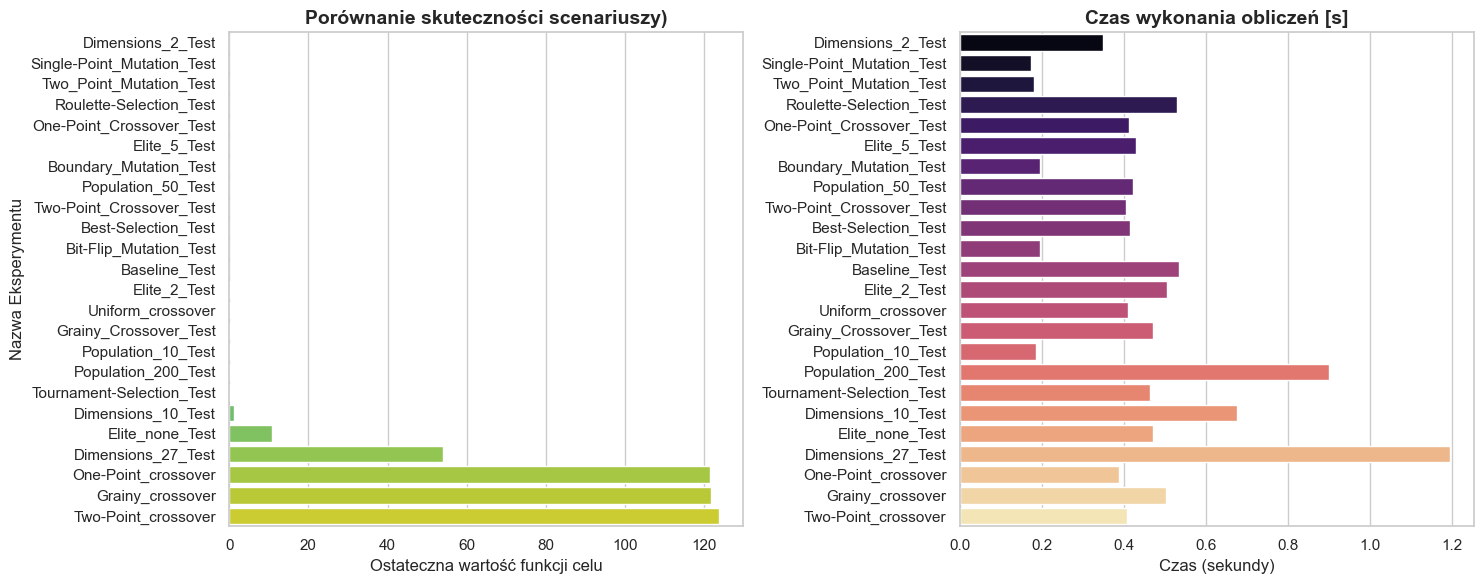

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Wykres 1: Najlepsza wartość (Precyzja)
plt.subplot(1, 2, 1)
sns.barplot(data=df_p1, y='experiment_name', x='best_value', palette='viridis')
plt.title('Porównanie skuteczności scenariuszy)', fontsize=14, fontweight='bold')
plt.xlabel('Ostateczna wartość funkcji celu')
plt.ylabel('Nazwa Eksperymentu')

# Wykres 2: Czas wykonania
plt.subplot(1, 2, 2)
sns.barplot(data=df_p1, y='experiment_name', x='execution_time', palette='magma')
plt.title('Czas wykonania obliczeń [s]', fontsize=14, fontweight='bold')
plt.xlabel('Czas (sekundy)')
plt.ylabel('')

plt.tight_layout()
plt.show()

## Analiza zbieżności i odchyleń

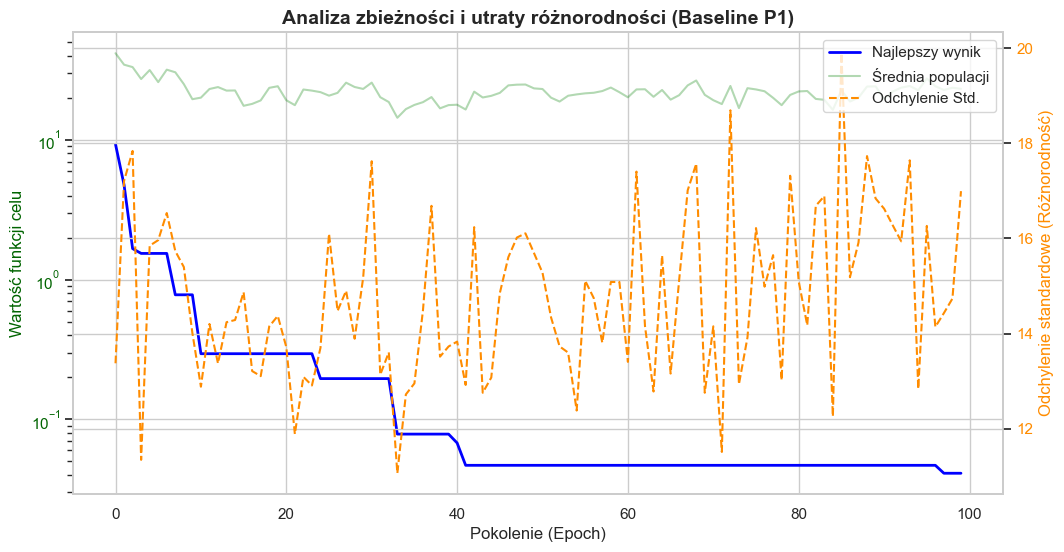

In [36]:
baseline_pattern = os.path.join(LOGS_DIR, "Baseline_Test_Binary_*_history.csv")
files = glob.glob(baseline_pattern)

if files:
    df_hist = pd.read_csv(files[0])
    
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Zbieżność (Fitness)
    ax1.set_xlabel('Pokolenie (Epoch)')
    ax1.set_ylabel('Wartość funkcji celu', color='darkgreen')
    ax1.plot(df_hist['epoch'], df_hist['best_value'], label='Najlepszy wynik', color='blue', linewidth=2)
    ax1.plot(df_hist['epoch'], df_hist['average_value'], label='Średnia populacji', color='green', alpha=0.3)
    ax1.tick_params(axis='y', labelcolor='darkgreen')
    ax1.set_yscale('log')

    # Różnorodność (Odchylenie Standardowe)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Odchylenie standardowe (Różnorodność)', color='darkorange')
    ax2.plot(df_hist['epoch'], df_hist['std_value'], label='Odchylenie Std.', color='darkorange', linestyle='--')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title('Analiza zbieżności i utraty różnorodności (Baseline P1)', fontsize=14, fontweight='bold')
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
    plt.show()
else:
    print("❌ Nie znaleziono pliku Baseline_Test dla P1. Upewnij się, że nazwa eksperymentu jest poprawna.")


## Szczegółowe Raporty Indywidualne


═══════════════════════════════════════════════════════════════════════════
  SZCZEGÓŁOWE INDYWIDUALNE RAPORTY TECHNICZNE (P1)
═══════════════════════════════════════════════════════════════════════════


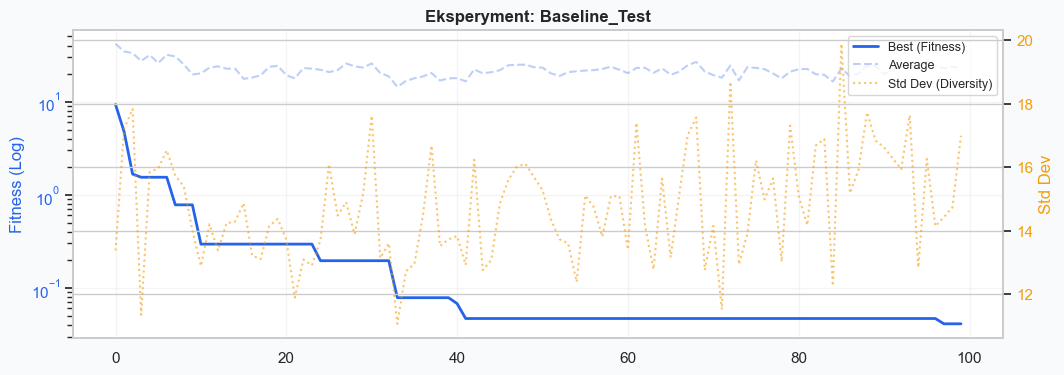

KONFIGURACJA DLA: Baseline_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


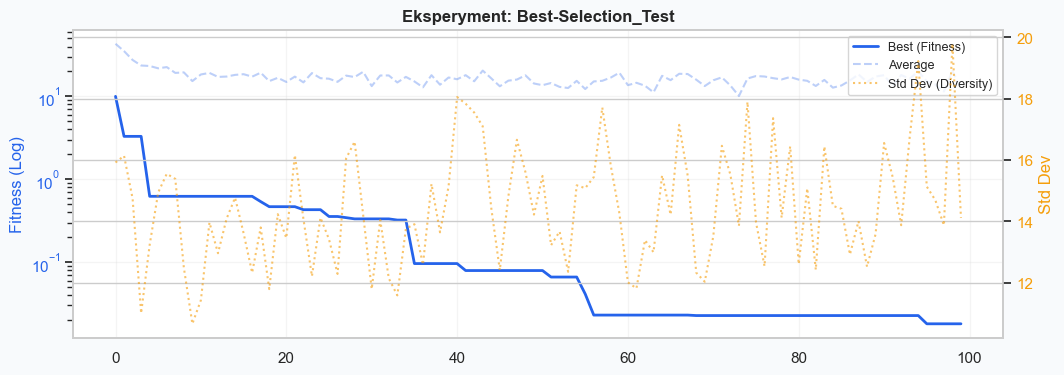

KONFIGURACJA DLA: Best-Selection_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: best | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


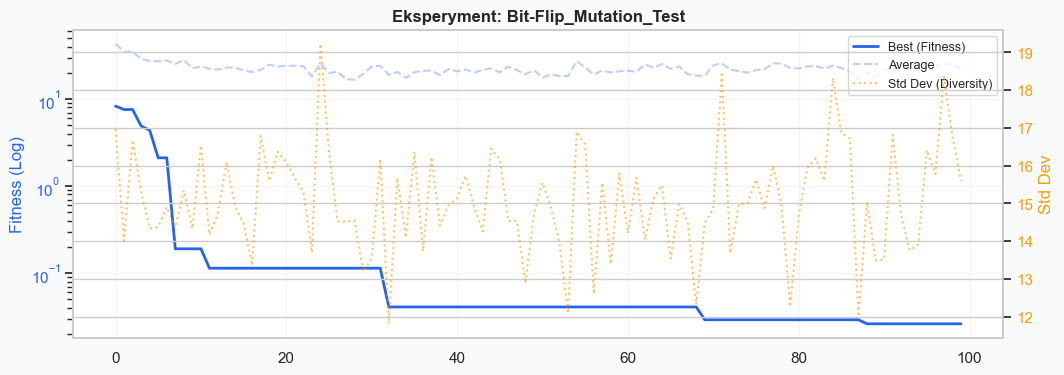

KONFIGURACJA DLA: Bit-Flip_Mutation_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


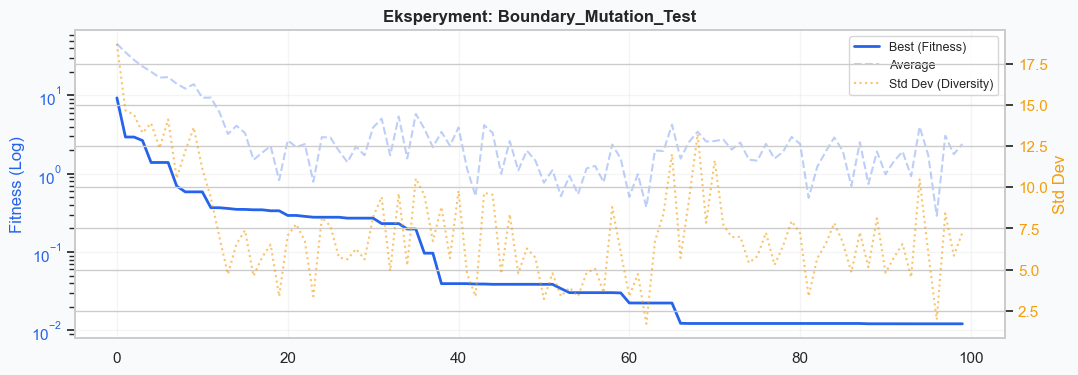

KONFIGURACJA DLA: Boundary_Mutation_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: boundary
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


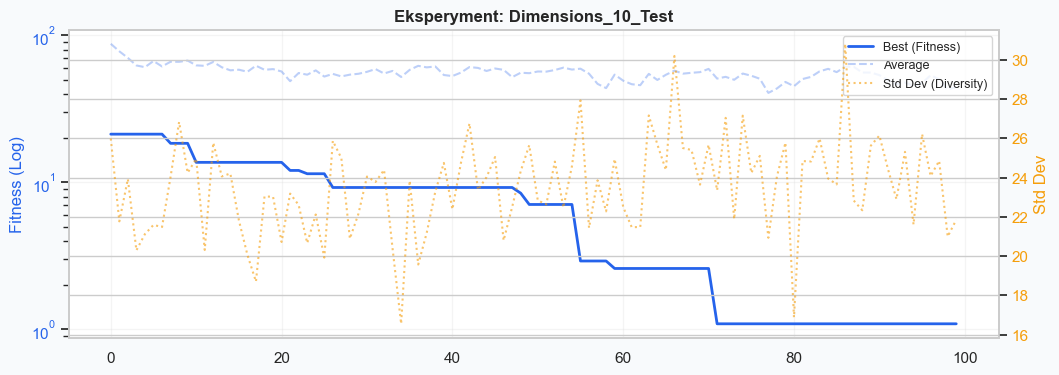

KONFIGURACJA DLA: Dimensions_10_Test
  • Pop: 50 | Gen: 100 | Dim: 10
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 200, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


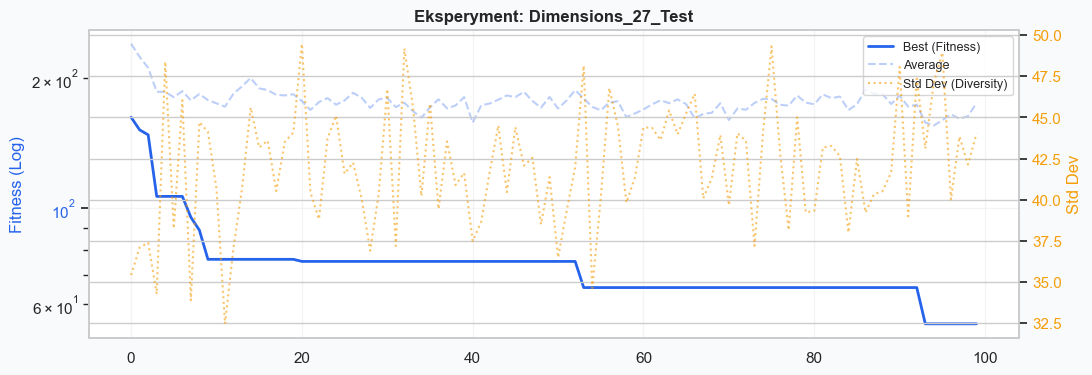

KONFIGURACJA DLA: Dimensions_27_Test
  • Pop: 50 | Gen: 100 | Dim: 27
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 540, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


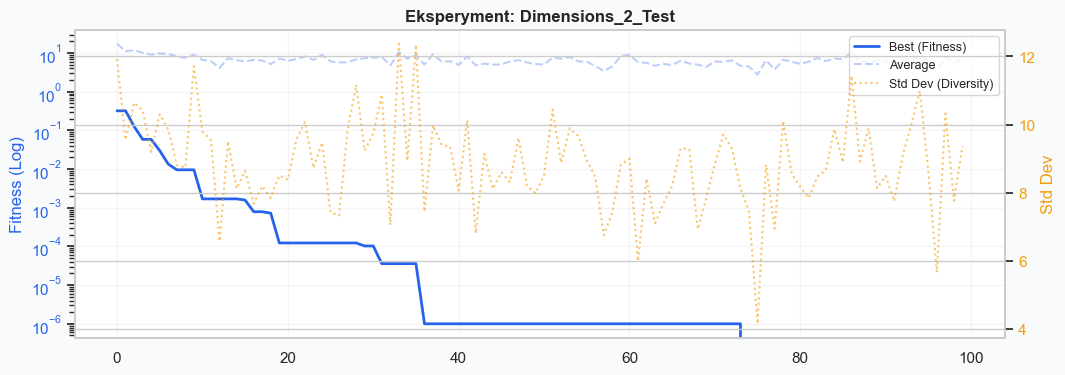

KONFIGURACJA DLA: Dimensions_2_Test
  • Pop: 50 | Gen: 100 | Dim: 2
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 40, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


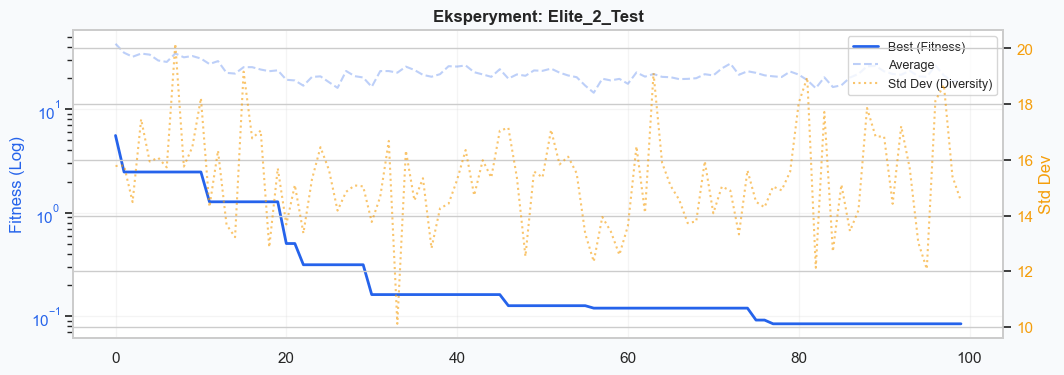

KONFIGURACJA DLA: Elite_2_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


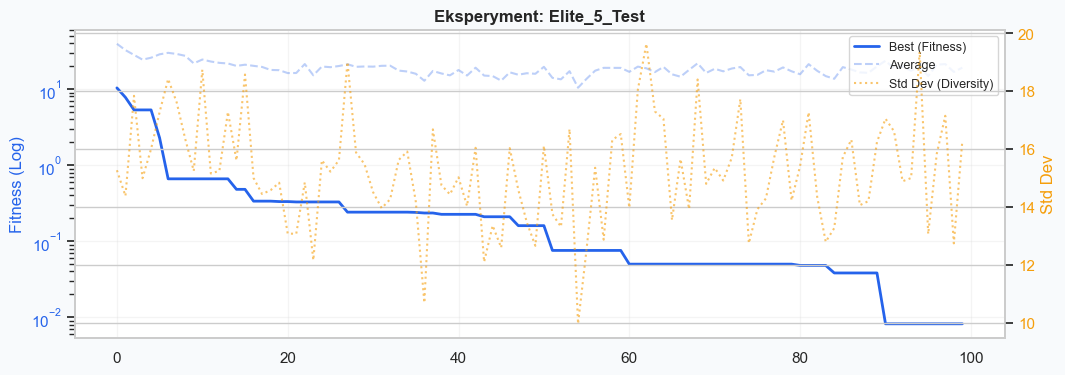

KONFIGURACJA DLA: Elite_5_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


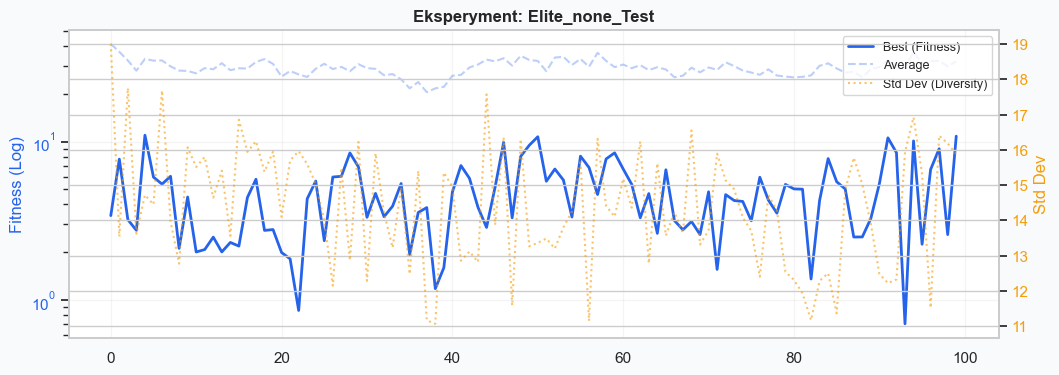

KONFIGURACJA DLA: Elite_none_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


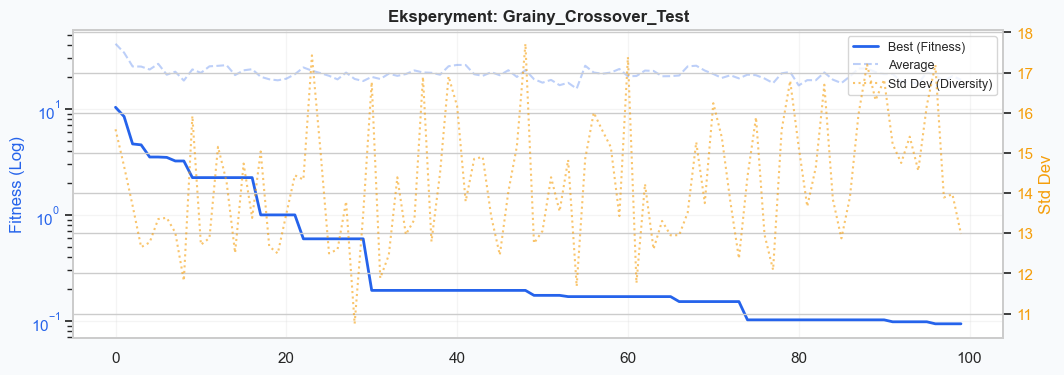

KONFIGURACJA DLA: Grainy_Crossover_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: grainy | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


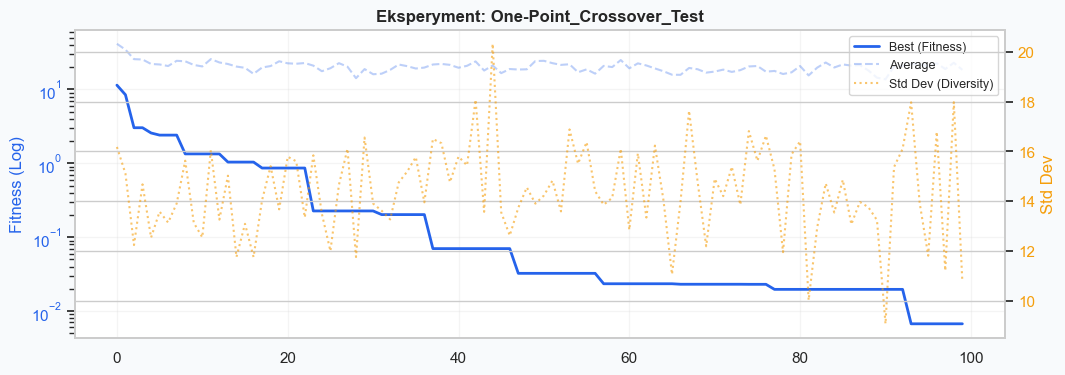

KONFIGURACJA DLA: One-Point_Crossover_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: one_point | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


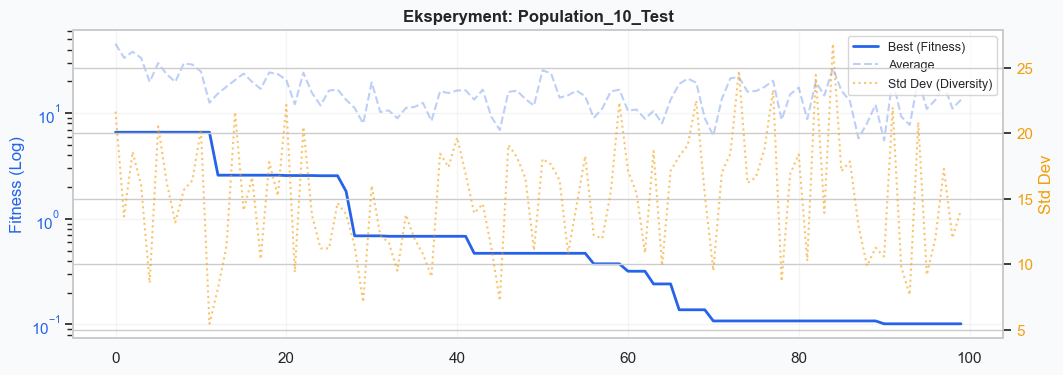

KONFIGURACJA DLA: Population_10_Test
  • Pop: 10 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


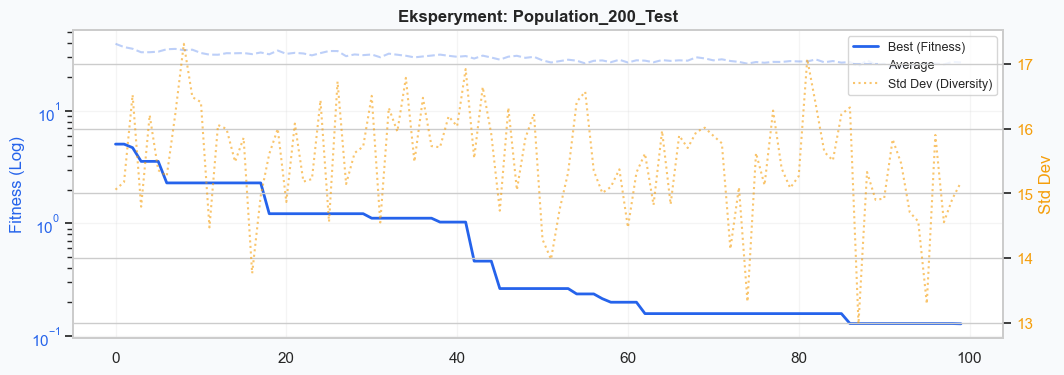

KONFIGURACJA DLA: Population_200_Test
  • Pop: 200 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


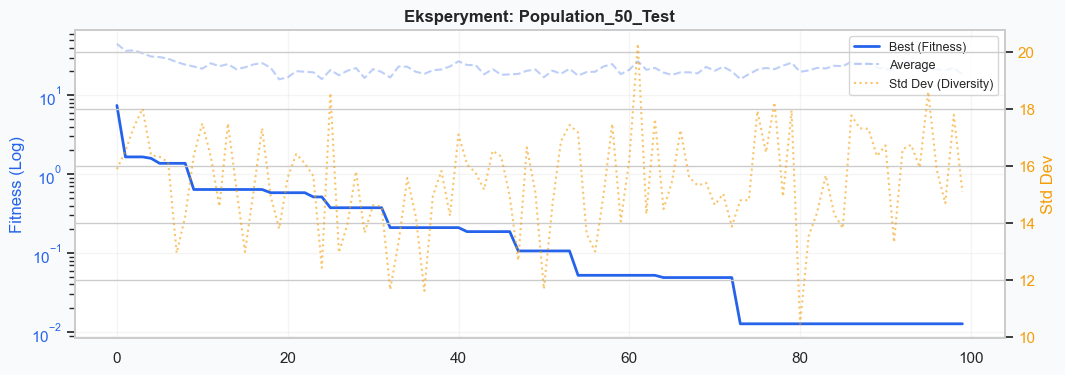

KONFIGURACJA DLA: Population_50_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


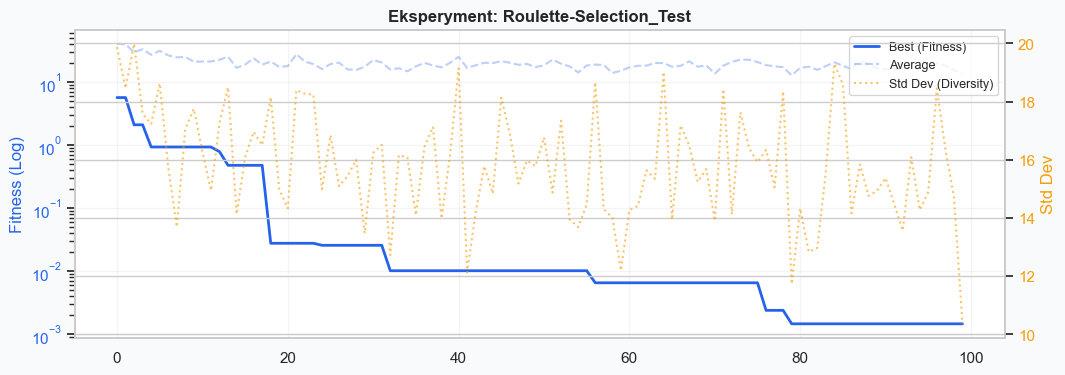

KONFIGURACJA DLA: Roulette-Selection_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: roulette | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


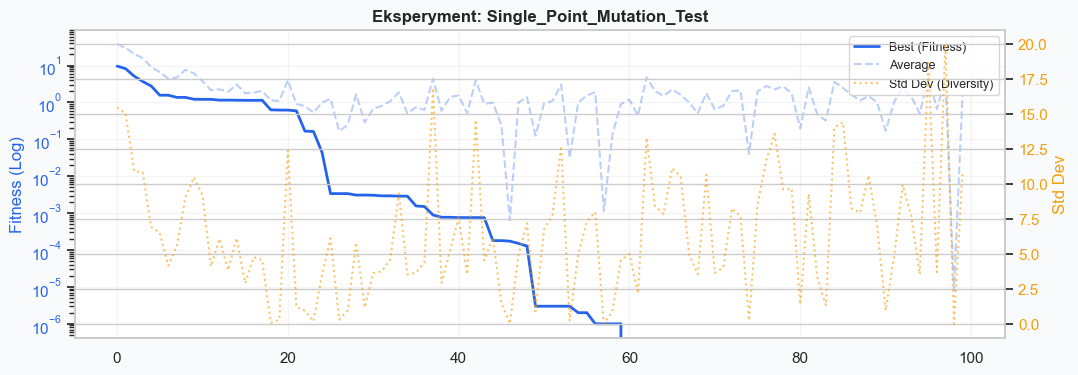

KONFIGURACJA DLA: Single_Point_Mutation_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: single_point
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


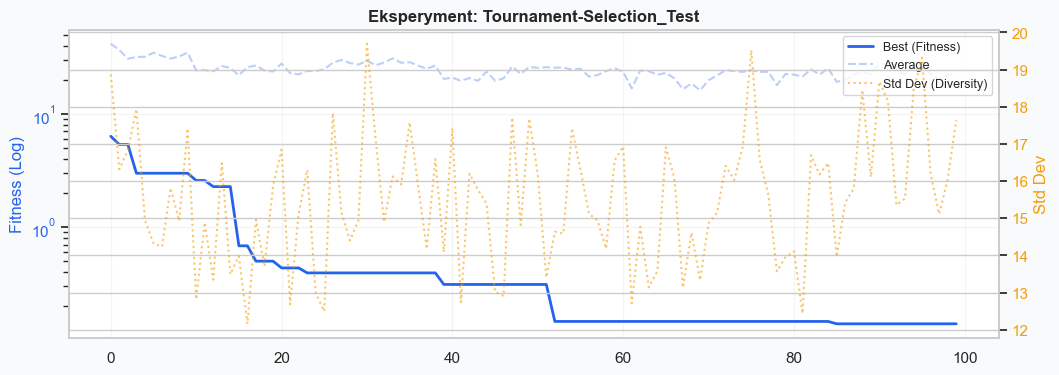

KONFIGURACJA DLA: Tournament-Selection_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


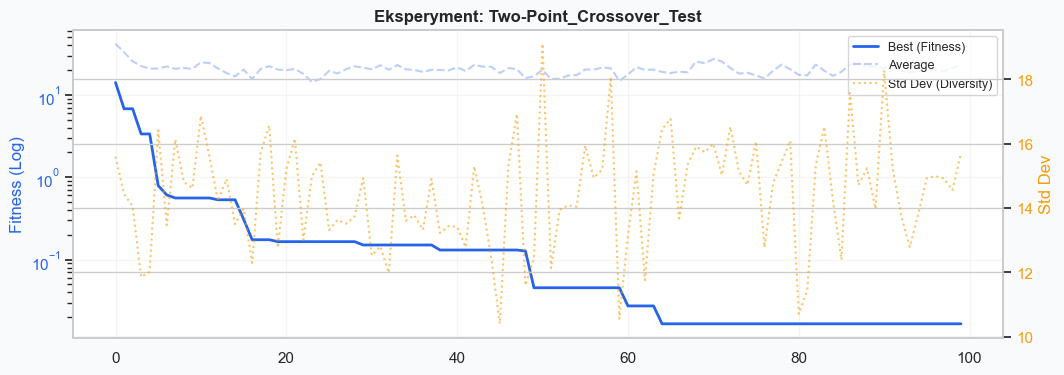

KONFIGURACJA DLA: Two-Point_Crossover_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: two_point | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


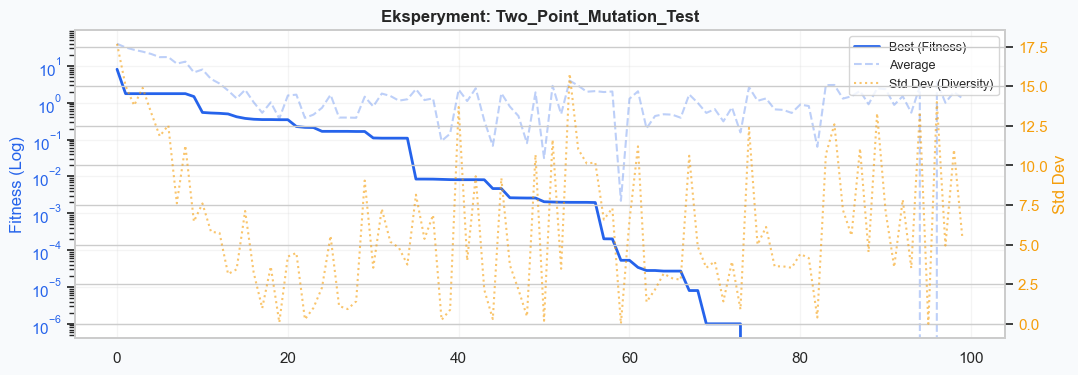

KONFIGURACJA DLA: Two_Point_Mutation_Test
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: two_point
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


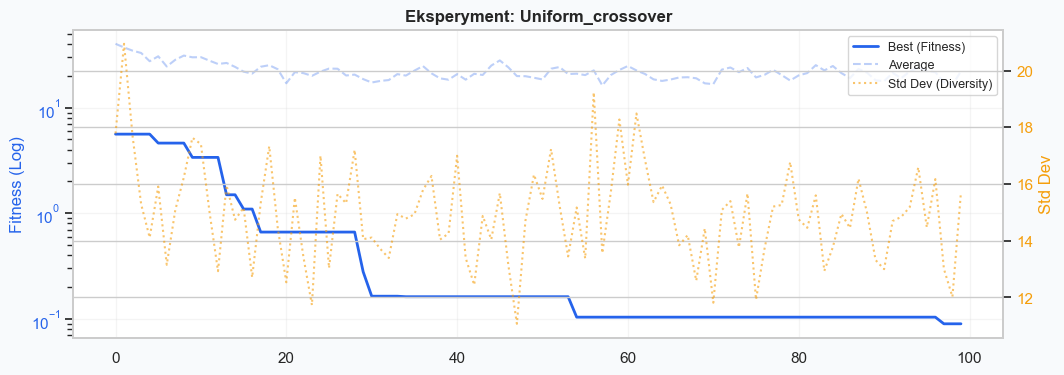

KONFIGURACJA DLA: Uniform_crossover
  • Pop: 50 | Gen: 100 | Dim: 5
  • Selekcja: tournament | Krzyżowanie: uniform | Mutacja: bit_flip
  • Specyficzne: chromosome_length: 100, inversion_rate: 0.05

───────────────────────────────────────────────────────────────────────────────────────────────


In [37]:
import json

print("\n" + "═"*75)
print("  SZCZEGÓŁOWE INDYWIDUALNE RAPORTY TECHNICZNE (P1)")
print("═"*75 + "\n")

history_files = sorted(glob.glob(os.path.join(LOGS_DIR, "*_Binary_*_history.csv")))

for csv_path in history_files:
    base_name = csv_path.replace("_history.csv", "")
    json_path = base_name + "_params.json"
    
    df_h = pd.read_csv(csv_path)
    
    params = {}
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            params = json.load(f)
    
    exp_display_name = params.get('experiment', {}).get('name', 'Nieznany')
    
    # --- WYKRES ANALITYCZNY ---
    fig, ax1 = plt.subplots(figsize=(12, 4), facecolor='#F8FAFC')
    
    # Fitness
    ax1.plot(df_h['epoch'], df_h['best_value'], color='#2563EB', label='Best (Fitness)', linewidth=2)
    ax1.plot(df_h['epoch'], df_h['average_value'], color='#2563EB', linestyle='--', label='Average', alpha=0.3)
    ax1.set_ylabel('Fitness (Log)', color='#2563EB')
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor='#2563EB')
    
    # Różnorodność
    ax2 = ax1.twinx()
    ax2.plot(df_h['epoch'], df_h['std_value'], color='#F59E0B', label='Std Dev (Diversity)', alpha=0.6, linestyle=':')
    ax2.set_ylabel('Std Dev', color='#F59E0B')
    ax2.tick_params(axis='y', labelcolor='#F59E0B')
    
    plt.title(f"Eksperyment: {exp_display_name}", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.2)
    
    # legenda
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=9)
    
    plt.show()
    
    # --- TABELA PARAMETRÓW (z nowego JSON-a) ---
    print(f"KONFIGURACJA DLA: {exp_display_name}")
    
    if params:
        p = params['parameters']
        m = params['methods']
        s = params.get('specifics', {})
        
        col1 = f"  • Pop: {p['population_size']} | Gen: {p['generations']} | Dim: {params['experiment']['dimensions']}"
        col2 = f"  • Selekcja: {m['selection']} | Krzyżowanie: {m['crossover']} | Mutacja: {m['mutation']}"
        
        print(col1)
        print(col2)
        if s:
            spec_str = "  • Specyficzne: " + ", ".join([f"{k}: {v}" for k, v in s.items()])
            print(spec_str)
            
    print("\n" + "─"*95 + "\n")


# Wnioski i Analiza Wyników Eksperymentów

W ramach projektu przeprowadziłam serię eksperymentów mających na celu zbadanie wpływu poszczególnych parametrów klasycznego algorytmu genetycznego na proces minimalizacji testowej funkcji sferycznej Hypersphere. Poniżej mamy szczegółową analizę z podziałem na badane scenariusze.

---

### 1. Scenariusz: Wpływ wielkości populacji
Badanie pokazuje klasyczny przypadek kompromisu pomiędzy czasem obliczeń a zdolnością eksploracji przestrzeni rozwiązań:

* **Mała populacja (10 osobników):** Algorytm zadziałał najszybciej (**0.1855 s**), jednak osiągnął słabszy wynik(**0.101508**).
* **Średnia populacja (50 osobników):** Stanowi idealny złoty środek. Osiągnęła optimum (**0.012677**) przy dobrym czasie (**0.4209 s**).
* **Duża populacja (200 osobników):** Paradoksalnie dała gorszy wynik (**0.12**) przy najdłuższym czasie obliczeń, który wzrósł ogromnie (**0.9006 s**).

* Zbyt duża populacja przy ograniczonej liczbie pokoleń (100) sprawia, że algorytm jest zbyt wolny i nie zdąży w pełni zbiec do minimum. Średnia populacja zapewnia optymalny wynik.

<br>

### 2. Scenariusz: Metody selekcji
Wybór metody reprodukcji miał drastyczny wpływ na sukces optymalizacji:

* * **Selekcja Ruletkowa:** Okazała się bezkonkurencyjna, osiągając optimum dla (**0.0014**). Zapewniła doskonały balans między promowaniem dobrych genów a utrzymaniem różnorodności.
**Selekcja Najlepszych (Best):** Poradziła sobie zaskakująco dobrze, szybko zawężając przeszukiwania (wynik **0.018**).
* **Selekcja Turniejowa:** Dała wyniki najsłabsze (**~0.13**), co może sugerować, że przy użytych parametrach (np. mały rozmiar turnieju i duża konkurencja) presja była zbyt agresywna i algorytm utknął w minimum lokalnym.

<br>

### 3. Scenariusz: Skalowalność problemu
Eksperyment obrazuje wykładniczy wzrost trudności problemu wraz ze wzrostem liczby zmiennych decyzyjnych (N):

* Dla **N=2** problem był prosty – algorytm znalazł idealne zero (0.000000) w bardzo krótkim czasie.
* Dla **N=10** czas obliczeń wzrósł , a wynik stracił swoją precyzję (**~ 1.1**).
* Dla **N=27** przestrzeń poszukiwań stała się tak ogromna, że liczba epok okazała się niewystarczająca. Czas wykonania był najdłuższy ze wszystkich testów minimalizacji (**1.19 s**), a wynik (**~ 54**) wskazuje, że algorytm nadal był w fazie schodzenia do minimum globalnego, aczkolwiek daleko od celu.

<br>

### 4. Scenariusz: Znaczenie Elitaryzmu
Zgodnie z teorią, ochrona najlepszego materiału genetycznego jest kluczowa dla stabilności. 

Eksperymenty jednoznacznie udowodniły, że elitaryzm jest krytycznym mechanizmem zabezpieczającym algorytm przed utratą dobrych rozwiązań. Wariant z szeroką elitą Elite_5 osiągnął rewelacyjny wynik na poziomie 0.008. Z kolei całkowite wyłączenie ochrony najlepszych osobników (Elite_none) spowodowało drastyczny spadek jakości (wynik 10.81). Bez elitaryzmu destrukcyjne działanie mutacji i krzyżowania prowadzi do niszczenia wypracowanych minimów lokalnych, przez co algorytm cofa się w rozwoju.

<br>

### 5. Scenariusz: Metody Krzyżowania
W trakcie testów metod krzyżowania zaobserwować można anomalię. O ile krzyżowanie jednorodne (`uniform`) zadziałało perfekcyjnie, o tyle metody `one_point`, `two_point` oraz `grainy` zakończyły działanie z wynikiem bliskim **125**.

**Błąd eksperymentu:** Wartość 125 nie jest przypadkowa. Dla funkcji Hypersphere o 5 wymiarach, maksimum na granicach dziedziny w przedziale od -5 do 5 wynosi dokładnie: 

`(-5)² * 5 = 125`
    
Dla tych trzech testów algorytm był optymalizowany do maksimum. Przyczyną tej anomalii jest zwykły błąd - pozostawienie parametru "Typ Optymalizacji" na wartości "Max" zamiast "Min" podczas konfiguracji. Ta sytuacja pokazuje, jak wrażliwe na warunki początkowe są eksperymenty optymalizacyjne.


Po przeprowadzeniu testów dla poprawnego typu optymalizacji, możemy wyciągnąć inne wnioski:
* Agresywne krzyżowanie jednorodne (Uniform) ustąpiło miejsca klasycznym metodom wielopunktowym.
* Najlepsze wyniki osiągnęły warianty One-Point (0.006) oraz Two-Point (0.016).
* Metody Uniform (~0.04-0.08) i Grainy (0.09) wypadły zauważalnie gorzej. Wynika to z faktu, że dla funkcji ciągłych reprezentowanych jako ciągi bitów, krzyżowanie jednorodne zbyt często rozrywa "bloki budujące" genów, podczas gdy punktowe metody lepiej zachowują strukturę dobrych rozwiązań.


## Czas vs jakość

In [38]:
plt.figure(figsize=(12, 6))

# FILTR DANYCH (usuwamy eksperyment MAX)
df_plot = df_p1[
    (df_p1['best_value'] < 5.0) & 
    (~df_p1['experiment_name'].str.contains('Dimensions_2', na=False))
].copy()

scatter = sns.scatterplot(
    data=df_plot, 
    x='execution_time', 
    y='best_value', 
    hue='crossover_method', 
    style='mutation_method', 
    s=150, 
    alpha=0.8,
    palette='deep'
)

plt.title('Czas wykonania vs. Jakość rozwiązania', fontsize=14, fontweight='bold')
plt.xlabel('Czas wykonania [sekundy]', fontsize=12)
plt.ylabel('Najlepsza wartość (Best Value) - Skala Log', fontsize=12)
plt.yscale('log')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.7)

for i in range(df_plot.shape[0]):
    plt.text(df_plot['execution_time'].iloc[i] + 0.01, 
             df_plot['best_value'].iloc[i], 
             df_plot['experiment_name'].iloc[i], 
             fontsize=8, alpha=0.7)

plt.subplots_adjust(right=0.75) 
plt.show()

Wykres przedstawia zestawienie dla problemu 5-wymiarowego. Z zestawienia celowo wykluczono test 'Dimensions_2'. Zmniejszenie wymiarowości problemu drastycznie redukuje przestrzeń poszukiwań, przez co algorytm dla 2 wymiarów osiąga o kilka rzędów wielkości lepszą precyzję (bliską zera absolutnego). Porównywanie go z problemem 5D na jednej skali zaburzyłoby analizę.

---

## Podsumowanie i Wnioski Końcowe (Algorytm Binarny)

Na podstawie nowej iteracji eksperymentów dla binarnej reprezentacji chromosomu, wspartej zaawansowanym systemem logowania i analizą odchylenia standardowego, sformułowano następujące wnioski techniczne:

### A. Krytyczna rola elitaryzmu (Zjawisko "zapominania")
Eksperymenty jednoznacznie udowodniły, że elitaryzm jest absolutnie niezbędny do zbieżności algorytmu binarnego. Wariant `Elite_5` osiągnął jeden z najlepszych wyników (0.008), podczas gdy całkowite wyłączenie ochrony najlepszych osobników (`Elite_none`) spowodowało drastyczny spadek jakości (wynik 10.81). Bez elitaryzmu destrukcyjne działanie mutacji i krzyżowania prowadzi do utraty wypracowanych już minimów lokalnych.

### B. Przewaga klasycznego krzyżowania w problemach ciągłych
Wbrew pierwotnym przypuszczeniom, agresywne krzyżowanie jednorodne (`Uniform`) ustąpiło miejsca krzyżowaniom wielopunktowym (`One-Point` oraz `Two-Point`, które osiągnęły wyniki rzędu 0.006 - 0.016). Dla funkcji ciągłych reprezentowanych jako ciągi bitów, krzyżowanie jednorodne zbyt często rozrywa wypracowane "bloki budujące" (building blocks) genów, podczas gdy krzyżowanie jedno- i dwupunktowe lepiej zachowuje strukturę dobrych rozwiązań wewnątrz chromosomu.

### C. Selekcja Ruletkowa a utrzymanie różnorodności
Zaskakująco dobre wyniki osiągnęła selekcja ruletkowa (`Roulette-Selection` - 0.0014). Choć teoretycznie ustępuje ona selekcji turniejowej pod kątem kontroli presji ewolucyjnej, w tym konkretnym przypadku pomogła ona najdłużej utrzymać pożądaną różnorodność genetyczną (wysokie odchylenie standardowe), zapobiegając przedwczesnej zbieżności, na którą cierpiały inne warianty.

### D. Klątwa wymiarowości (Zależność wykładnicza)
Dane doskonale ilustrują trudność problemów wielowymiarowych. Dla przestrzeni 2D algorytm zbiegł do idealnego zera (0.000000). Zwiększenie liczby wymiarów ujawniło tzw. klątwę wymiarowości: dla 5D błąd wynosił ~0.04, dla 10D już ~1.09, a dla 27 wymiarów algorytm zatrzymał się na wartości 53.91. Sztywna siatka dyskretyzacji binarnej całkowicie dławi się przy dużych przestrzeniach.

### E. Złożoność obliczeniowa i wnioski końcowe
Algorytm binarny, choć poprawnie rozwiązuje podstawowe problemy optymalizacyjne (zarówno MIN jak i MAX - co udowodniły wyłączone z wykresów testy z wynikami >120), charakteryzuje się dużym narzutem obliczeniowym na procesy kodowania/dekodowania. Jego zmagania z precyzją w wyższych wymiarach i szybka utrata różnorodności populacji stanowią jednoznaczną motywację do zastosowania **kodowania rzeczywistego (Projekt 2)**, które powinno rozwiązać problem drastycznych skoków na siatce wartości.